# Project Description:

The purpose of this project is to implement a neural network that performs the translation of mathematical formulae from traditional **infix notation**—where the operator appears between two operands—to **postfix** (also known as Reverse Polish Notation), where the operator follows the operands.

Infix notation is the most commonly used in human-readable mathematics (e.g., a + b), but it is inherently ambiguous without additional syntactic aids such as parentheses or operator precedence rules. This ambiguity arises because different parse trees can correspond to the same expression depending on how operations are grouped.

In contrast, postfix notation eliminates the need for parentheses entirely. The order of operations is explicitly encoded by the position of the operators relative to the operands, making it more suitable for stack-based evaluation and easier to parse programmatically.

**Example:**

Consider the ambiguous infix expression:
a + b * c

This expression can be parsed in at least two different ways:

Interpretation (Infix):	(a + b) * c	   
Equivalent Postfix: ab+c*

Interpretation (Infix):	a + (b * c)	          
Equivalent Postfix: abc*+


This project aims to learn such disambiguations and generate the correct postfix form from a given infix expression using a data-driven approach based on neural networks. To simplify the task and control the complexity of expressions, we restrict our dataset to formulae with a maximum syntactic depth of 3. This means that the abstract syntax trees representing these expressions will have at most three levels, ensuring that the neural network operates on a bounded and manageable set of possible structures.

In [1]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from collections import Counter
import gdown

We build formulae using 5 identifiers a,b,c,d,e and 4 binary operators +,-,*,/.
For simplicity we do not take advantage of precedence or associativity rules for infix notation, and suppose that all binary operations as always fully parenthesizes: (e1 op e2).

In [2]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcde')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK'] #may use junk in autoregressive generation

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
id_to_token = {i: tok for tok, i in token_to_id.items()}
VOCAB_SIZE = len(VOCAB)
PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 3
MAX_LEN = 4*2**MAX_DEPTH -2 #enough to fit expressions at given depth (+ EOS)

In [3]:
# -------------------- Expression Generation --------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.5:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

def tokenize(expr):
    return [c for c in expr if c in token_to_id]

def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence[stack[-1]] >= precedence[token]:
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            stack.pop()
    while stack:
        output.append(stack.pop())
    return output

def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]
    return ids + [PAD_ID] * (max_len - len(ids))

def decode_sequence(token_ids, id_to_token, pad_token='PAD', eos_token='EOS'):
    """
    Converts a list of token IDs into a readable string by decoding tokens.
    Stops at the first EOS token if present, and ignores PAD tokens.
    """
    tokens = []
    for token_id in token_ids:
        token = id_to_token.get(token_id, '?')
        if token == eos_token:
            break
        if token != pad_token:
            tokens.append(token)
    return ' '.join(tokens)

def generate_dataset(n,max_depth=MAX_DEPTH):
    X, Y = [], []
    for _ in range(n):
        expr = generate_infix_expression(MAX_DEPTH)
        #expr = expr_gen.generate(max_depth=max_dthep)
        infix = tokenize(expr)
        postfix = infix_to_postfix(infix)
        X.append(encode(infix))
        Y.append(encode(postfix))
    return np.array(X), np.array(Y)

#you might use the shift function for teacher-forcing
def shift_right(seqs):
    shifted = np.zeros_like(seqs)
    shifted[:, 1:] = seqs[:, :-1]
    shifted[:, 0] = SOS_ID
    return shifted

Let us define a simple dataset, and inspect a few samples.

In [4]:
X_train, Y_train = generate_dataset(10000)
decoder_input_train = shift_right(Y_train)

# Dataset
X_val, Y_val = generate_dataset(1000)
decoder_input_val = shift_right(Y_val)

In [10]:
i =  np.random.randint(10000)
print(i)
print("infix : ",decode_sequence(X_train[i],id_to_token))
print("posfix notation: ",decode_sequence(Y_train[i],id_to_token))
print("teacher forcing : ", decode_sequence(decoder_input_train[i],id_to_token))

607
infix :  ( c * ( ( b / d ) + ( d - b ) ) )
posfix notation:  c b d / d b - + *
teacher forcing :  SOS c b d / d b - + *


# Constraints
* You may use any architecture (decoder-only, encoder-decoder, or other).

* The maximum number of parameters is 2 million.

* Beam search is not allowed.

* You may adapt the formula generator to your needs, but preserve its core logic—especially the frequency distribution of formulas by depth, as it may significantly influence model performance.

* You may train your model using a pre-generated fixed dataset (e.g., an array) or directly use an on-the-fly generator.




# Evaluation

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of
the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

* It's more informative than exact match (which is often 0)

* It’s tighter than edit distance: focuses on generation flow

* Captures where the model starts to make errors



In [11]:
def prefix_accuracy_single(y_true, y_pred, id_to_token, eos_id=EOS_ID, verbose=False):
    t_str = decode_sequence(y_true, id_to_token).split(' EOS')[0]
    p_str = decode_sequence(y_pred, id_to_token).split(' EOS')[0]
    t_tokens = t_str.strip().split()
    p_tokens = p_str.strip().split()
    max_len = max(len(t_tokens), len(p_tokens))

    match_len = sum(x == y for x, y in zip(t_tokens, p_tokens))
    score = match_len / max_len if max_len>0 else 0

    if verbose:
        print("TARGET :", ' '.join(t_tokens))
        print("PREDICT:", ' '.join(p_tokens))
        print(f"PREFIX MATCH: {match_len}/{len(t_tokens)} → {score:.2f}")

    return score

For the exam, evaluate you model on a test set of 20 expressions. Repeat this evaluation 10 times, and return the mean and std for this rounds.

In [12]:
def test(no=20,rounds=10):
  rscores =[]
  for i in range(rounds):
    print("round=",i)
    X_test, Y_test = generate_dataset(no)
    scores = []
    for j in range(no):
      encoder_input=X_test[j]
      generated = autoregressive_decode(model, encoder_input)[1:] #remove SOS
      scores.append(prefix_accuracy_single(Y_test[j], generated, id_to_token))
    rscores.append(np.mean(scores))
  return np.mean(rscores),np.std(rscores)

# res, std = test(20,10)
# print("score=",res,"std=",std)

Be sure to evalutate the generator: your model may only take as input the expression in infix format and return its translation to postifix.

If you are usuing an encoder-decoder model, generation must be done autoregressively.

# What to deliver

As usual you are supposed to deliver a single notebook witten in Keras. You are auhtorized to use Keras3 with pytorch as backend if your prefer.

Do no upload a zip file: the submission will be rejected.

The python notebook should have a clear documentation of the training phase, possibly with its history.

You should be able to provide the network paramters upon request. Even better, consider a way to upload them inside your notebook using gdown.

# ***Solution***

#### 🔁 Autoregressive Greedy Decoding

This function generates tokens one by one from the Transformer decoder using **greedy decoding**. It starts with the `SOS` token and iteratively predicts the next token by selecting the one with the highest probability. The process continues until the `EOS` token is generated or the maximum sequence length (`MAX_LEN`) is reached.

- Inputs: encoder output and partially generated decoder input  
- At each step, predicts the next token and appends it to the decoder input  
- Stops when `EOS` token is produced or `MAX_LEN` is reached  

Returns the full generated token sequence as a NumPy array.

In [13]:
# Function: Autoregressively decode using greedy token generation.
def autoregressive_decode(model, encoder_input):
    """
    Performs greedy decoding from a Transformer decoder given a fixed encoder input.

    Starts from the SOS token and predicts each next token until EOS or MAX_LEN.

    Parameters:
    -----------
    model : tf.keras.Model
        Trained Transformer model.
    encoder_input : np.ndarray
        Encoded infix input sequence.

    Returns:
    --------
    np.ndarray
        Generated token IDs of the predicted postfix sequence.
    """
    decoder_input = np.zeros((1, MAX_LEN), dtype=int)
    decoder_input[0, 0] = SOS_ID
    for t in range(1, MAX_LEN):
        preds = model.predict([encoder_input[np.newaxis], decoder_input], verbose=0)
        next_token = np.argmax(preds[0, t - 1])
        decoder_input[0, t] = next_token
        if next_token == EOS_ID:
            break
    return decoder_input[0]

#### 🔄 Dynamic Data Sampling via Keras Generator
To decouple training from static datasets and allow infinite sampling from the target distribution, we implement a Sequence-based **on-the-fly data generator**. This implements a dynamic infix-to-postfix training samples generator compatible with Keras training loops. 


This class creates training data during training, instead of loading it all at once. It uses `tf.keras.utils.Sequence`, so it works with `model.fit()` in Keras. It naturally produces a **non-uniform depth distribution** due to the recursive structure and probabilistic branching (e.g., `random.random() < 0.5`).

- Each batch contains new **random** infix expressions and their postfix forms.
- Inputs and targets are encoded, and decoder inputs are created using shift_right.
- Returns data in the format `((encoder_input, decoder_input), target_output)` for encoder-decoder models.
- The depth of expressions is random, based on how generate_infix_expression works.
- This helps avoid memory issues and increases variation in training data.

In [14]:
# Class: Keras-compatible on-the-fly data generator for training.
class InfixToPostfixGenerator(tf.keras.utils.Sequence):
    """
    Implements a dynamic data generator that yields batches of input-output pairs
    (infix to postfix) with limited AST depth, suitable for infinite data training.

    Parameters:
    -----------
    batch_size : int
        Number of samples per batch.
    steps_per_epoch : int
        Number of steps to simulate one epoch.

    Methods:
    --------
    __len__() : int
        Returns the number of batches per epoch.
    __getitem__(idx) : tuple
        Returns a tuple ((encoder_inputs, decoder_inputs), target_outputs).
    """
    def __init__(self, batch_size=64, steps_per_epoch=200, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        X, Y = generate_dataset(self.batch_size)
        decoder_input = shift_right(Y)
        return (X, decoder_input), Y

### 🧱 Model Architecture: Transformer Encoder-Decoder
We implement a **Transformer-based encoder-decoder** model using TensorFlow/Keras, optimized for our symbolic sequence conversion tasks i.e. infix to postfix. This architecture is well-suited for handling the long-range dependencies and structural reordering inherent in mathematical expressions.

The model builds abstract token relationships layer by layer, the encoder captures the full context of the infix expression, while the decoder leverages this context to generate the corresponding postfix expressions in an autoregressive manner.

### 🔹 Model Details:

- **Inputs**:
  - `encoder_inputs`: input tensor of shape `(MAX_LEN,)` for infix expressions
  - `decoder_inputs`: input tensor of shape `(MAX_LEN,)` for shifted postfix sequences (teacher forcing)

- **Hyperparameters**:
  - `embed_dim`: size of token/position embeddings
  - `num_heads`: number of attention heads
  - `ff_dim`: hidden size in feedforward layers
  - `num_layers`: number of encoder/decoder blocks
  - `dropout`: dropout rate for attention and feedforward

- **Embeddings**:
  - Shared token embedding for encoder and decoder
  - Position embedding layer for sequence order (`MAX_LEN` positions)

- **Encoder**:
  - Adds token + position embeddings
  - `num_layers` blocks:
    - Multi-head self-attention
    - Feedforward layers with ReLU
    - Layer norm + residual connections

- **Decoder**:
  - Same structure with:
    - Masked self-attention (`use_causal_mask=True`)
    - Cross-attention over encoder outputs
    - Feedforward + residual connections

- **Output**:
  - Final `Dense` layer with `softmax` over `VOCAB_SIZE`

- **Returns**:
  - A `tf.keras.Model` with `[encoder_inputs, decoder_inputs]` → softmax output

In [15]:
# Function: Build a Transformer encoder-decoder model for infix-to-postfix translation.
def build_transformer(embed_dim=64, num_heads=4, ff_dim=128, num_layers=2, dropout=0.1):
    """
    Constructs a lightweight encoder-decoder Transformer model with shared embeddings.

    Parameters:
    -----------
    embed_dim : int
        Dimensionality of token embeddings.
    num_heads : int
        Number of attention heads.
    ff_dim : int
        Hidden size of the feedforward layer.
    num_layers : int
        Number of encoder and decoder blocks.
    dropout : float
        Dropout rate for attention and feedforward layers.

    Returns:
    --------
    model : tf.keras.Model
        A compiled Transformer model for sequence transduction.
    """
    encoder_inputs = layers.Input(shape=(MAX_LEN,), name='encoder_inputs')
    decoder_inputs = layers.Input(shape=(MAX_LEN,), name='decoder_inputs')

    shared_embedding = layers.Embedding(VOCAB_SIZE, embed_dim, name='shared_embedding')
    position_embedding = layers.Embedding(input_dim=MAX_LEN, output_dim=embed_dim, name='position_embedding')
    positions = tf.range(start=0, limit=MAX_LEN, delta=1)

    encoder_embeddings = shared_embedding(encoder_inputs) + position_embedding(positions)
    x = encoder_embeddings
    for _ in range(num_layers):
        x = layers.LayerNormalization(epsilon=1e-6)(x + layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout)(x, x))
        ffn = layers.Dense(ff_dim, activation='relu')(x)
        ffn = layers.Dense(embed_dim)(ffn)
        x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

    encoder_outputs = x

    decoder_embeddings = shared_embedding(decoder_inputs) + position_embedding(positions)
    y = decoder_embeddings
    for _ in range(num_layers):
        y = layers.LayerNormalization(epsilon=1e-6)(y + layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout)(y, y, use_causal_mask=True))
        y = layers.LayerNormalization(epsilon=1e-6)(y + layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout)(y, encoder_outputs))
        ffn = layers.Dense(ff_dim, activation='relu')(y)
        ffn = layers.Dense(embed_dim)(ffn)
        y = layers.LayerNormalization(epsilon=1e-6)(y + ffn)

    outputs = layers.Dense(VOCAB_SIZE, activation='softmax')(y)
    return models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs)

#### 🎯 Loss and Evaluation: Masked Objective & Prefix Accuracy
- **Masked Loss:** Computes categorical cross-entropy ignoring padding (`PAD_ID`) tokens by applying a mask. This prevents padded positions from affecting the loss value during training.

- **Masked Accuracy:** Calculates token-level accuracy excluding padding tokens, ensuring evaluation only considers meaningful tokens.

In alignment with the project’s specification, we evaluate sequence outputs using **prefix accuracy**, and **Masked accuracy** is only used for plotting and comparing training accuracy over epochs.

In [16]:
# Function: Compute categorical cross-entropy ignoring PAD tokens.
def masked_loss(y_true, y_pred, loss_fn):
    """
    Calculates cross-entropy loss while ignoring padding positions.

    Parameters:
    -----------
    y_true : tensor
        Ground truth token IDs.
    y_pred : tensor
        Predicted token distributions.
    loss_fn : callable
        A loss function that computes token-level cross-entropy.

    Returns:
    --------
    tf.Tensor
        Scalar loss value normalized over non-padding tokens.
    """
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    loss = loss_fn(y_true, y_pred)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)


# Function: Token-level accuracy ignoring padding tokens.
def masked_accuracy(y_true, y_pred):
    """
    Computes token-level categorical accuracy, ignoring PAD tokens.

    Parameters:
    -----------
    y_true : tensor
        Ground truth token IDs.
    y_pred : tensor
        Predicted token distributions.

    Returns:
    --------
    tf.Tensor
        Scalar accuracy score.
    """
    y_pred = tf.argmax(y_pred, axis=-1)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    matches = tf.cast(tf.equal(y_true, y_pred), tf.float32)
    return tf.reduce_sum(matches * mask) / tf.reduce_sum(mask)

#### 🌲 Abstract Syntax Tree Depth Computation
This function calculates the depth of the AST for a fully parenthesized infix expression e.g., `((a + b) * c)`. We will use this function for distribution sampling counting for our validation data (which is optional).

In [17]:
# Function: Compute the syntactic depth (AST depth) of a fully parenthesized infix expression.
def compute_ast_depth(expr):
    """
    Computes the abstract syntax tree (AST) depth of a fully parenthesized infix mathematical expression.

    Parameters:
    -----------
    expr : str
        Fully parenthesized infix expression, such as '((a + b) * c)'.

    Returns:
    --------
    int
        The AST depth of the expression, i.e., the maximum depth of nested binary operations.
    """
    tokens = list(expr.replace(" ", ""))  # Remove whitespace for parsing

    def helper(index):
        if tokens[index] == '(':
            left_depth, next_index = helper(index + 1)
            op = tokens[next_index]  # Operator
            right_depth, next_index = helper(next_index + 1)
            assert tokens[next_index] == ')'
            return max(left_depth, right_depth) + 1, next_index + 1
        else:
            return 0, index + 1  # Identifier (base case)

    depth, _ = helper(0)
    return depth

#### 📊 Depth-Controlled Dataset Generator (For Validation Dataset Only)
We are using this function to create a dataset of infix-to-postfix expression pairs with a controlled, uniform distribution over AST depths from `min_depth` to `max_depth`. For each depth level, it generates exactly `n_per_depth` expressions whose actual AST depth matches the target.

**Note:**
- We optionally retain it for validation, to care about uniform depth. 
- We are not using it inside the generator as we do not want balanced-depth for the training data.

In [18]:
# Function: Generate dataset with uniform AST depth distribution
def generate_dataset_uniform_depth(n_per_depth, min_depth=0, max_depth=MAX_DEPTH):
    """
    Generates a dataset of infix expressions and their corresponding postfix translations,
    ensuring a uniform distribution across a specified range of AST depths.

    Parameters:
    -----------
    n_per_depth : int
        Number of valid expression pairs to generate for each depth level.
    min_depth : int
        Minimum AST depth to include in the dataset.
    max_depth : int
        Maximum AST depth to include in the dataset.

    Returns:
    --------
    X : np.ndarray
        Encoded infix expressions.
    Y : np.ndarray
        Encoded postfix expressions.
    """
    X, Y = [], []
    for depth in range(min_depth, max_depth + 1):
        count = 0
        while count < n_per_depth:
            expr = generate_infix_expression(depth)
            if compute_ast_depth(expr) == depth:
                infix = tokenize(expr)
                postfix = infix_to_postfix(infix)
                X.append(encode(infix))
                Y.append(encode(postfix))
                count += 1
    return np.array(X), np.array(Y)


#### 📈 Depth Distribution Analysis (Validation Only)
- Checks whether depth levels are uniformly represented in the generated data for validation. 
- Balanced validation data is crucial to avoid bias towards simpler (shallower) expressions. 

In [19]:
# Function: Plot a histogram of expression AST depths using a bar chart.
def plot_depth_distribution(counter, title="Depth Distribution"):
    """
    Plots the distribution of abstract syntax tree (AST) depths for infix expressions
    as a bar chart. Useful for analyzing training data complexity and ensuring
    balanced sampling across expression depths.

    Parameters:
    -----------
    counter : collections.Counter
        Frequency count of expression depths.
    title : str
        Title of the plot window.
    """
    # Sort depth levels for ordered plotting
    items = sorted(counter.items())
    depths, counts = zip(*items)

    # Create the figure and plot bars
    plt.figure(figsize=(6, 4))
    bars = plt.bar(depths, counts, color='skyblue', edgecolor='black')

    # Axis labels and title
    plt.xlabel("Depth")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(depths)

    # Annotate each bar with its count
    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(count),
            ha='center',
            fontsize=9
        )

    # Add horizontal grid lines for readability
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Optimize spacing and display
    plt.tight_layout()
    plt.show()

#### Visual confirmation for validation data uniformity

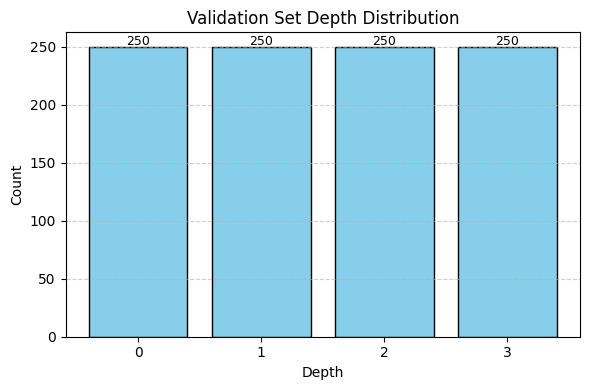

In [20]:
# Create validation dataset and verify distribution
X_val, Y_val = generate_dataset_uniform_depth(n_per_depth=250, min_depth=0, max_depth=MAX_DEPTH)
decoder_input_val = shift_right(Y_val)

depths_val = [compute_ast_depth(decode_sequence(x, id_to_token)) for x in X_val]
depth_counter_val = Counter(depths_val)
plot_depth_distribution(depth_counter_val, "Validation Set Depth Distribution")

#### 🏗️ Model Training
We train the Transformer using **on-the-fly batch generation**, which offers virtually infinite variation and enforces robustness. Additionally, we apply **early stopping** based on validation loss to prevent long training time as it ensures we don't train for longer than necessary. A brief summary of each component is as follows:
- **Loss Function**  
  Sparse categorical crossentropy applied per token with probabilities as input.

- **Model Compilation**  
  Transformer compiled with Adam optimizer and custom masked loss and accuracy to ignore padding.

- **Early Stopping**  
  Stops training after 5 epochs without validation loss improvement, restoring best weights.

- **Training**  
  On-the-fly data generator feeds fresh training data each epoch; validation on fixed data; max 20 epochs with callbacks.

In [21]:
# -------------------- Loss Function --------------------
# Sparse categorical crossentropy will be applied to each token in the output sequence.
# `from_logits=False` indicates the model outputs probabilities (due to softmax).
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none') 


# -------------------- Build and Compile the Transformer Model --------------------
# Initializes the Transformer architecture defined earlier.
model = build_transformer()

# Compile the model with:
# - Adam optimizer (default learning rate 0.001)
# - Custom masked loss that ignores PAD tokens
# - Custom masked accuracy for sequence-level evaluation
model.compile(optimizer='adam',
              loss=lambda y_true, y_pred: masked_loss(y_true, y_pred, loss_fn),
              metrics=[masked_accuracy])


# Print model summary to show total parameters and architecture.
model.summary()

# -------------------- Early Stopping Callback --------------------
# Stops training if the validation loss does not improve for 5 consecutive epochs.
# Automatically restores the best weights based on validation loss.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# -------------------- Training --------------------
# On-the-fly training data generator that yields new examples each epoch.
train_gen = InfixToPostfixGenerator()

# Train the model using:
# - On-the-fly training generator
# - Validation data (fixed, possibly uniformly distributed by depth)
# - Up to 20 epochs
# - Early stopping and learning rate logging callbacks
history = model.fit(
    train_gen,
    validation_data=([X_val, decoder_input_val], Y_val),
    epochs=20,
    callbacks=[early_stop]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, 30, 64)    │        960 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │ decoder_inputs[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ shared_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 64)    │          0 │ shared_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 64)    │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 64)    │          0 │ add_5[0][0],    

 Total params: 467,727 (1.78 MB)

 Trainable params: 467,727 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - loss: 1.4719 - masked_accuracy: 0.4622 - val_loss: 0.0748 - val_masked_accuracy: 0.9734
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.1314 - masked_accuracy: 0.9569 - val_loss: 0.0115 - val_masked_accuracy: 0.9955
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0326 - masked_accuracy: 0.9904 - val_loss: 0.0028 - val_masked_accuracy: 0.9995
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0203 - masked_accuracy: 0.9943 - val_loss: 5.1892e-04 - val_masked_accuracy: 1.0000
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0121 - masked_accuracy: 0.9966 - val_loss: 9.7211e-04 - val_masked_accuracy: 1.0000
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0044 - masked_accuracy: 0.9988 - val_loss: 0.0048 - val_masked_accuracy: 0.9986
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0131 - masked_accuracy: 0.9964 - val_loss: 1.3305e-04 - val_mask

#### 📏 Evaluation with Prefix Accuracy

In [22]:
# Evaluate model performance using prefix accuracy metric across multiple rounds
mean, std = test(20, 10)
print(f"📊 Final Prefix Accuracy: mean={mean:.4f}, std={std:.4f}")
print(f"🧠 Total Model Parameters: {model.count_params():,}")

round= 0
round= 1
round= 2
round= 3
round= 4
round= 5
round= 6
round= 7
round= 8
round= 9
📊 Final Prefix Accuracy: mean=1.0000, std=0.0000
🧠 Total Model Parameters: 467,727


#### 📈 Visualizing Training History
Plotting the training curves of loss and accuracy across epochs allows us to verify that:

- The model learns progressively and stably
- Validation accuracy improves in tandem with training

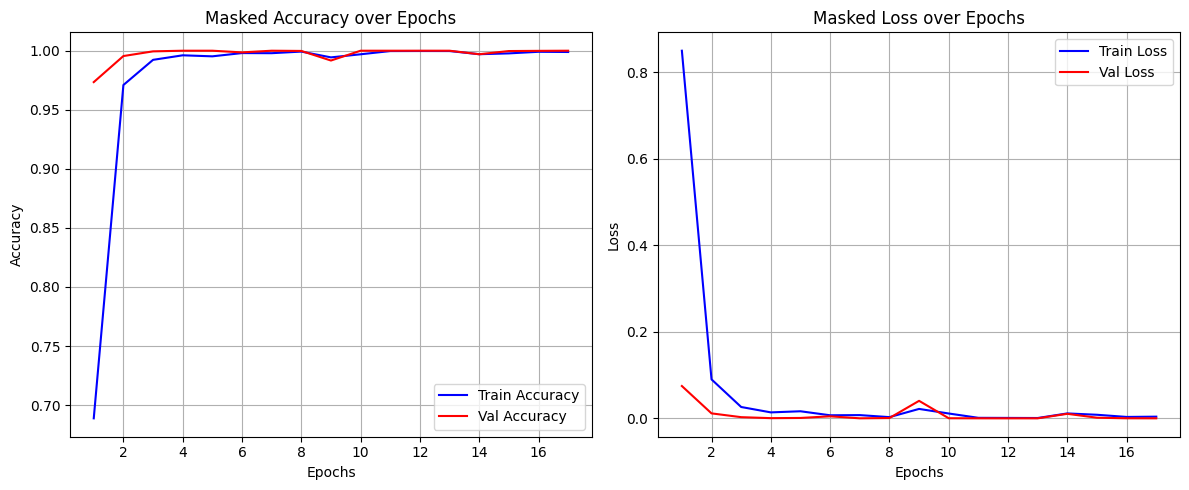

In [23]:
# Function: Plot training and validation loss/accuracy history.
def plot_training_history(history):
    """
    Visualizes training progress in terms of loss and masked accuracy across epochs.

    Parameters:
    -----------
    history : tf.keras.callbacks.History
        Training history object returned by model.fit().
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['masked_accuracy'], 'b-', label='Train Accuracy')
    plt.plot(epochs, history.history['val_masked_accuracy'], 'r-', label='Val Accuracy')
    plt.title('Masked Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'r-', label='Val Loss')
    plt.title('Masked Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
plot_training_history(history)

#### 💾 Saving Model
- To preserve the trained weights for future inference and evaluation, we serialize the model using Keras’s `save_weights()` method.

In [24]:
# Save model weights locally for future reuse or submission
model.save_weights("transformer_infix2postfix.weights.h5")
print("✅ Model weights saved.")

✅ Model weights saved.


- These saved weights are also uploaded to cloud storage manually for convenience and reproducibility.

#### 🔁 Reloading Model Weights from Google Drive using `gdown`  
Downloads previously trained model weights and reloads them into the Transformer.

In [25]:
# Reload pre-trained model weights from Google Drive using gdown

# https://drive.google.com/file/d/1ucymuI4MBDAagAAnNPDnuDrjFEpZk2ji/view?usp=sharing
file_id = "1ucymuI4MBDAagAAnNPDnuDrjFEpZk2ji"
url = f"https://drive.google.com/uc?id={file_id}&confirm=t"
output = "transformer_infix2postfix.weights.h5"

gdown.download(url, output, quiet=False)
model.load_weights(output)
print("✅ Weights loaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1ucymuI4MBDAagAAnNPDnuDrjFEpZk2ji&confirm=t
To: c:\Users\hp\Downloads\Deep Learning Assignment\transformer_infix2postfix.weights.h5
100%|██████████| 5.85M/5.85M [00:00<00:00, 9.77MB/s]


✅ Weights loaded successfully.


#### 📊 Re-Evaluation After Weight Reload
Re-evaluates the model using the provided `test()` function to ensure consistency after loading saved weights. Confirms that the restored model performs as expected.

In [26]:
# Evaluate model again to confirm restored weights are valid
mean, std = test(20, 10)
print(f"📊 Prefix accuracy after reloading: mean={mean:.4f}, std={std:.4f}")

round= 0
round= 1
round= 2
round= 3
round= 4
round= 5
round= 6
round= 7
round= 8
round= 9
📊 Prefix accuracy after reloading: mean=1.0000, std=0.0000


#### 🔍 Qualitative Prediction Analysis

This section performs a visual sanity check on the model’s output. For each test case:

- A single infix expression is generated.
- The model decodes its predicted postfix form step-by-step, starting from the `SOS` token.
- Prediction stops at `EOS` or `MAX_LEN`.

We compare:

- `Infix:` input expression  
- `Postfix:` ground truth output  
- `Predicted:` model output

In [27]:
# Function: Decode a sequence of token IDs into a readable token string.
def decode_seq(token_ids):
    """
    Decodes a list of token IDs into a string representation using the vocabulary.

    Parameters:
    -----------
    token_ids : list or np.ndarray
        Sequence of integer token IDs.

    Returns:
    --------
    str
        Space-separated decoded token sequence.
    """
    return decode_sequence(token_ids, id_to_token)


# Section: Display qualitative predictions for sanity check
for _ in range(10):
    Xs, Ys = generate_dataset(1)
    x, y = Xs[0], Ys[0]
    dec = np.zeros((1, MAX_LEN), dtype=int)
    dec[0, 0] = SOS_ID
    for t in range(1, MAX_LEN):
        pred = model([x[np.newaxis], dec], training=False)
        dec[0, t] = tf.argmax(pred[0, t - 1]).numpy()
        if dec[0, t] == EOS_ID:
            break
    print("Infix:    ", decode_seq(x))
    print("Postfix:  ", decode_seq(y))
    print("Predicted:", decode_seq(dec[0][1:]))  # Remove SOS
    print("-" * 30)


Infix:     ( d - e )
Postfix:   d e -
Predicted: d e -
------------------------------
Infix:     ( e - e )
Postfix:   e e -
Predicted: e e -
------------------------------
Infix:     ( ( d - ( e * a ) ) - ( b / b ) )
Postfix:   d e a * - b b / -
Predicted: d e a * - b b / -
------------------------------
Infix:     ( c - ( d / a ) )
Postfix:   c d a / -
Predicted: c d a / -
------------------------------
Infix:     ( b + a )
Postfix:   b a +
Predicted: b a +
------------------------------
Infix:     ( ( b / c ) + ( ( e + a ) - ( b - b ) ) )
Postfix:   b c / e a + b b - - +
Predicted: b c / e a + b b - - +
------------------------------
Infix:     ( a / e )
Postfix:   a e /
Predicted: a e /
------------------------------
Infix:     ( ( ( d + e ) / ( e + c ) ) / ( ( b * e ) + ( b - c ) ) )
Postfix:   d e + e c + / b e * b c - + /
Predicted: d e + e c + / b e * b c - + /
------------------------------
Infix:     e
Postfix:   e
Predicted: e
------------------------------
Infix:     ( b * (

### 📊 Report Summary

- **Data Generation**: On-the-fly generation of infix expressions up to depth 3.  

- **Validation** was performed on a static set of 1,000 uniformly distributed samples set (0–3).
  
- **Model Architecture**: Transformer encoder-decoder with shared embeddings, 2 layers, 96-dim embeddings, 4 attention heads (~460K params). 

- **Training**: 
  - Uses **teacher forcing** via shifted decoder input
  - **Masked sparse crossentropy** loss (ignores `PAD` tokens)
  - **Masked accuracy** metric
  - **Early stopping** based on validation loss with best weight restoration

- **Decoding**: Greedy autoregressive decoding starting with `SOS`.

- **Evaluation**: 
  - **Prefix accuracy** over 10 rounds, 20 expressions each.

- **Results**:  
  - **Prefix Accuracy (mean ± std)**: `1.0000 ± 0.0000`

- **Saved**: Best model weights stored (`.h5` format).

---

In [29]:
# 📋 Print a detailed summary of training outcome and model configuration

# Final metrics from training history
final_epoch = len(history.history['loss']) - 1
train_acc = history.history['masked_accuracy'][final_epoch] * 100
val_acc = history.history['val_masked_accuracy'][final_epoch] * 100
train_loss = history.history['loss'][final_epoch]
val_loss = history.history['val_loss'][final_epoch]

# Optimizer
optimizer = model.optimizer
optimizer_name = type(optimizer).__name__

# Embedding dimension
embedding_layer = model.get_layer('shared_embedding')
embedding_dim = embedding_layer.output_dim

# Attention heads and dropout (from first MHA layer)
first_mha = next(layer for layer in model.layers if isinstance(layer, tf.keras.layers.MultiHeadAttention))
attention_heads = first_mha.num_heads
dropout_rate = first_mha.dropout

# Feedforward dimension (from first relu-activated Dense layer)
ff_layer = next(layer for layer in model.layers if isinstance(layer, tf.keras.layers.Dense) and layer.activation.__name__ == 'relu')
feedforward_dim = ff_layer.units

# Count transformer blocks by structure (based on MultiHeadAttention usage pattern)
# Rough estimate: every encoder and decoder layer includes 2+ MHA blocks
mha_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.MultiHeadAttention)]
# Assuming structure is: N encoder layers with 1 MHA + N decoder layers with 2 MHA
num_mha = len(mha_layers)
decoder_layers = num_mha // 3
encoder_layers = num_mha - 2 * decoder_layers

# Decoding strategy (constant for now)
decoding_strategy = 'Autoregressive (Greedy)'
beam_search_used = False

# Parameter count
total_params = model.count_params()

# 📝 Report model configuration and training performance
print(f"""\n📦 Epochs Completed: {final_epoch + 1}

📈 Training Accuracy:     {train_acc:.2f}%
📉 Validation Accuracy:   {val_acc:.2f}%
🧮 Final Training Loss:   ~{train_loss:.6f}
🧪 Final Validation Loss: ~{val_loss:.6f}
🧠 Optimizer:             {optimizer_name}
""")

print("📊 Prefix Accuracy Evaluation")
print(f"- Mean Prefix Accuracy:      {mean:.4f}")
print(f"- Std Dev (Prefix Accuracy): {std:.4f}")
print(f"- Decoding Strategy:         {decoding_strategy}")
print(f"- Beam Search:               {'✅ Used' if beam_search_used else '❌ Not Used (per constraints)'}\n")

print("🧠 Model Architecture")
print(f"- Type:                   Encoder-Decoder Transformer")
print(f"- Embedding Dimension:    {embedding_dim}")
print(f"- Attention Heads:        {attention_heads}")
print(f"- Encoder Layers:         {encoder_layers}")
print(f"- Decoder Layers:         {decoder_layers}")
print(f"- Feedforward Dimension:  {feedforward_dim}")
print(f"- Dropout:                {dropout_rate}")
print(f"- Parameters:             {total_params:,} (✅ Under 2M limit)")

print("\n💾 Model weights saved and reloadable using gdown.")



📦 Epochs Completed: 17

📈 Training Accuracy:     99.89%
📉 Validation Accuracy:   100.00%
🧮 Final Training Loss:   ~0.003954
🧪 Final Validation Loss: ~0.000139
🧠 Optimizer:             Adam

📊 Prefix Accuracy Evaluation
- Mean Prefix Accuracy:      1.0000
- Std Dev (Prefix Accuracy): 0.0000
- Decoding Strategy:         Autoregressive (Greedy)
- Beam Search:               ❌ Not Used (per constraints)

🧠 Model Architecture
- Type:                   Encoder-Decoder Transformer
- Embedding Dimension:    64
- Attention Heads:        4
- Encoder Layers:         2
- Decoder Layers:         2
- Feedforward Dimension:  128
- Dropout:                0.1
- Parameters:             467,727 (✅ Under 2M limit)

💾 Model weights saved and reloadable using gdown.
